# Оценка точности технологии PPP-AR на станциях сети IGS
### Материалы для статьи в «Геодезию и Картографию»

**Метод:** Precise Point Positioning с фиксацией фазовых неоднозначностей (PPP-AR)  
**Программное обеспечение:** RTKLIB  
**Эфемериды и поправки:** CODE (Центр определения орбит в Европе)  
**Период:** Январь 2025 г. (DOY 001–030)  
**Сеть:** IGS (International GNSS Service)  

> **Примечание.** Оценка точности выполнена раздельно по трём координатным составляющим N (север), E (восток), U (вертикаль), поскольку они являются независимыми случайными величинами с различными законами распределения и дисперсиями.

In [1]:
# ── Настройки ─────────────────────────────────────────────────────────────────
IGS_CSV = '/Users/sergeidolin/collaborative-service/igs_batch_jan2025.csv'

IQR_FACTOR       = 3.0   # коэффициент IQR для отсева выбросов
FIX_Q_VALUES     = {1}   # Q=1 — фиксированное решение
FLOAT_Q_VALUES   = {6}   # Q=6 — плавающее PPP-решение
CONFIDENCE_LEVEL = 0.95  # доверительная вероятность

# Пороги классов точности по каждой компоненте (мм)
# N и E — горизонталь, U — вертикаль (обычно в 2–3 раза хуже)
GRADE_THR_H = [5, 10, 20]          # для N и E
GRADE_THR_V = [10, 20, 50]         # для U
GRADE_LABELS_H = ['≤5 мм', '5–10 мм', '10–20 мм', '>20 мм']
GRADE_LABELS_V = ['≤10 мм', '10–20 мм', '20–50 мм', '>50 мм']

FIG_DPI    = 150
FIG_FONT   = 11
SAVE_FIGS  = True
FIG_PREFIX = 'fig_igs'

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, HTML

matplotlib.rcParams.update({
    'font.size':         FIG_FONT,
    'axes.titlesize':    FIG_FONT + 1,
    'axes.labelsize':    FIG_FONT,
    'xtick.labelsize':   FIG_FONT - 1,
    'ytick.labelsize':   FIG_FONT - 1,
    'legend.fontsize':   FIG_FONT - 1,
    'figure.dpi':        FIG_DPI,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
})

CLR = {'N': '#2980b9', 'E': '#e67e22', 'U': '#27ae60'}

def rms(a):
    a = np.asarray(a, dtype=float)
    return float(np.sqrt(np.mean(a**2))) if len(a) else np.nan

def ci_rms(a, p=CONFIDENCE_LEVEL):
    """ДИ для СКП через распределение хи-квадрат."""
    n = len(a)
    if n < 2: return np.nan, np.nan
    r = rms(a)
    alpha = 1 - p
    lo = r * np.sqrt(n / sp_stats.chi2.ppf(1-alpha/2, df=n))
    hi = r * np.sqrt(n / sp_stats.chi2.ppf(  alpha/2, df=n))
    return lo, hi

def savefig(name):
    if SAVE_FIGS:
        path = f'{FIG_PREFIX}_{name}.png'
        plt.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
        print(f'  → {path}')

def grade_counts(vals_mm, thresholds, labels):
    result, prev = [], 0
    for thr, lbl in zip(thresholds, labels[:-1]):
        c = int(np.sum((vals_mm > prev) & (vals_mm <= thr)))
        result.append((lbl, c, 100.0*c/len(vals_mm)))
        prev = thr
    c = int(np.sum(vals_mm > thresholds[-1]))
    result.append((labels[-1], c, 100.0*c/len(vals_mm)))
    return result

print('Готово.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sergeidolin/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/sergeidolin/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/sergeidolin/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.start()
  

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sergeidolin/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/sergeidolin/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/sergeidolin/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 711, in start
    self.io_loop.start()
  

AttributeError: _ARRAY_API not found

Готово.


In [3]:
# ── Загрузка и предобработка ──────────────────────────────────────────────────
df_raw = pd.read_csv(IGS_CSV, low_memory=False)
df_raw.columns = df_raw.columns.str.strip()
if 'city' not in df_raw.columns:
    df_raw.insert(df_raw.columns.get_loc('station')+1, 'city', '')
for col in ('lat','lon','h_m','q','nsat','dN_m','dE_m','dU_m','duration_s'):
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
df_raw['date'] = pd.to_datetime(df_raw['date'], errors='coerce')
df_raw['doy']  = df_raw['date'].dt.day_of_year

mask_ok = (
    (df_raw['status'].str.strip().str.lower() == 'ok')
    & (df_raw['lat'].abs() > 1e-6)
    & df_raw['dN_m'].notna() & df_raw['dE_m'].notna() & df_raw['dU_m'].notna()
    & ~((df_raw['dN_m'].abs()<1e-9)&(df_raw['dE_m'].abs()<1e-9)&(df_raw['dU_m'].abs()<1e-9))
)
df_ok = df_raw[mask_ok].copy()
N_ok  = len(df_ok)

# IQR-фильтр выбросов — раздельно по каждой компоненте
mask_iqr = pd.Series(True, index=df_ok.index)
iqr_bounds = {}
for col in ('dN_m','dE_m','dU_m'):
    q1, q3 = df_ok[col].quantile(0.25), df_ok[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - IQR_FACTOR*iqr, q3 + IQR_FACTOR*iqr
    iqr_bounds[col] = (lo*1000, hi*1000)
    mask_iqr &= df_ok[col].between(lo, hi)

df   = df_ok[mask_iqr].copy()
N_out = N_ok - len(df)

df_fix   = df[df['q'].isin(FIX_Q_VALUES)]
df_float = df[df['q'].isin(FLOAT_Q_VALUES)]

print(f'Строк всего          : {len(df_raw):>7d}')
print(f'После фильтра ok     : {N_ok:>7d}')
print(f'Удалено выбросов     : {N_out:>7d}  ({100*N_out/N_ok:.1f}%)')
print(f'Для анализа          : {len(df):>7d}')
print(f'  FIX  (Q=1)         : {len(df_fix):>7d}  ({100*len(df_fix)/len(df):.1f}%)')
print(f'  float(Q=6)         : {len(df_float):>7d}  ({100*len(df_float)/len(df):.1f}%)')
print(f'Пунктов              : {df["station"].nunique():>7d}')
print(f'Период               : DOY {df["doy"].min()}–{df["doy"].max()}'
      f'  ({df["date"].min().date()} – {df["date"].max().date()})')
print('\nГраницы IQR-фильтра (мм):')
for col,(lo,hi) in iqr_bounds.items():
    print(f'  {col}: [{lo:.1f} ; {hi:.1f}]')

Строк всего          :   53340
После фильтра ok     :   10694
Удалено выбросов     :    1077  (10.1%)
Для анализа          :    9617
  FIX  (Q=1)         :    9410  (97.8%)
  float(Q=6)         :     207  (2.2%)
Пунктов              :     289
Период               : DOY 1–31  (2025-01-01 – 2025-01-31)

Границы IQR-фильтра (мм):
  dN_m: [-21.2 ; 24.3]
  dE_m: [-29.1 ; 31.1]
  dU_m: [-64.2 ; 56.9]


---
## 1. Описательная статистика

In [4]:
stat_rows = []
for subset_lbl, subset in [('Все решения', df), ('FIX (Q=1)', df_fix), ('Float PPP (Q=6)', df_float)]:
    if len(subset) == 0: continue
    for comp, clbl in [('dN_m','N'),('dE_m','E'),('dU_m','U')]:
        a  = subset[comp].values
        mm = a * 1000
        lo, hi = ci_rms(a)
        samp = mm[:5000] if len(mm) >= 3 else mm
        _, p_norm = sp_stats.shapiro(samp) if len(samp) >= 3 else (None, None)
        stat_rows.append({
            'Выборка': subset_lbl,
            'Компонента': clbl,
            'N': len(mm),
            'μ, мм': f'{np.mean(mm):.2f}',
            'σ, мм': f'{np.std(mm,ddof=1):.2f}',
            'СКП, мм': f'{rms(a)*1000:.2f}',
            'ДИ 95% [мм;мм]': f'[{lo*1000:.2f};{hi*1000:.2f}]',
            'Мин, мм': f'{mm.min():.2f}',
            'Макс, мм': f'{mm.max():.2f}',
            'Асимметрия': f'{float(sp_stats.skew(mm)):.3f}',
            'Эксцесс': f'{float(sp_stats.kurtosis(mm)):.3f}',
            'p-Shapiro': f'{p_norm:.4f}' if p_norm is not None else '—',
        })

df_stat = pd.DataFrame(stat_rows).set_index(['Выборка','Компонента'])
print('=== Описательная статистика остатков PPP-AR (мм) ===')
display(df_stat)

=== Описательная статистика остатков PPP-AR (мм) ===


N  μ, мм  σ, мм СКП, мм ДИ 95% [мм;мм] Мин, мм  \
Выборка         Компонента                                                      
Все решения     N           9617   1.88   5.25    5.57    [5.50;5.65]  -21.00   
                E           9617   0.94   6.87    6.93    [6.84;7.03]  -28.60   
                U           9617  -3.50  13.63   14.07  [13.88;14.27]  -64.20   
FIX (Q=1)       N           9410   1.95   5.19    5.54    [5.46;5.62]  -21.00   
                E           9410   1.01   6.71    6.79    [6.69;6.89]  -28.60   
                U           9410  -3.48  13.43   13.88  [13.68;14.08]  -64.20   
Float PPP (Q=6) N            207  -1.42   6.75    6.88    [6.28;7.61]  -21.00   
                E            207  -2.04  11.62   11.77  [10.73;13.02]  -26.40   
                U            207  -4.65  20.71   21.18  [19.32;23.43]  -58.20   

                           Макс, мм Асимметрия Эксцесс p-Shapiro  
Выборка         Компонента                                        
Все решения     N             23.70      0.022   2.130    0.0000  
                E             31.10     -0.248   2.925    0.0000  
                U             56.20      0.056   1.497    0.0000  
FIX (Q=1)       N             23.70      0.059   2.179    0.0000  
                E             31.10     -0.207   3.044    0.0000  
                U             55.90      0.048   1.471    0.0000  
Float PPP (Q=6) N             18.70     -0.019   0.422    0.1298  
                E             24.60     -0.043  -0.374    0.0483  
                U             56.20      0.236   0.286    0.1713

---
## 2. Гистограммы с наложением нормального распределения

  → fig_igs_01_histograms.png


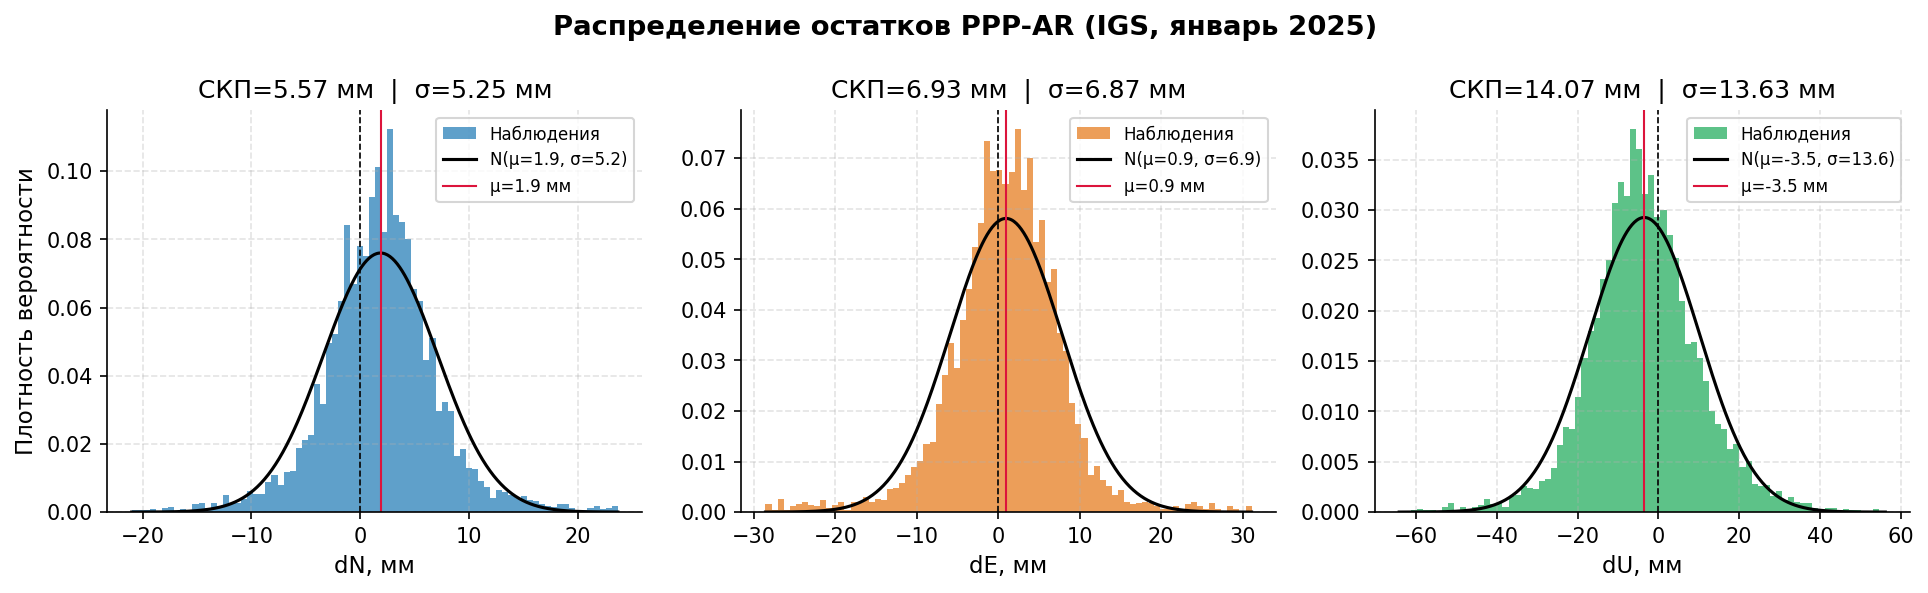

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Распределение остатков PPP-AR (IGS, январь 2025)', fontweight='bold')

for ax, col, lbl, clr in zip(axes,
        ['dN_m','dE_m','dU_m'], ['dN, мм','dE, мм','dU, мм'],
        [CLR['N'], CLR['E'], CLR['U']]):
    vals = df[col].values * 1000
    mu, sigma = np.mean(vals), np.std(vals, ddof=1)
    r = rms(df[col].values) * 1000
    ax.hist(vals, bins=80, density=True, color=clr, alpha=0.75,
            edgecolor='none', label='Наблюдения')
    x = np.linspace(vals.min(), vals.max(), 400)
    ax.plot(x, sp_stats.norm.pdf(x, mu, sigma), 'k-', lw=1.5,
            label=f'N(μ={mu:.1f}, σ={sigma:.1f})')
    ax.axvline(0,  color='black',   lw=0.8, ls='--')
    ax.axvline(mu, color='crimson', lw=1.0, ls='-', label=f'μ={mu:.1f} мм')
    ax.set_xlabel(lbl)
    ax.set_ylabel('Плотность вероятности' if ax is axes[0] else '')
    ax.set_title(f'СКП={r:.2f} мм  |  σ={sigma:.2f} мм')
    ax.legend(fontsize=8)

plt.tight_layout()
savefig('01_histograms')
plt.show()

---
## 3. Q-Q графики (проверка нормальности)

  → fig_igs_02_qqplot.png


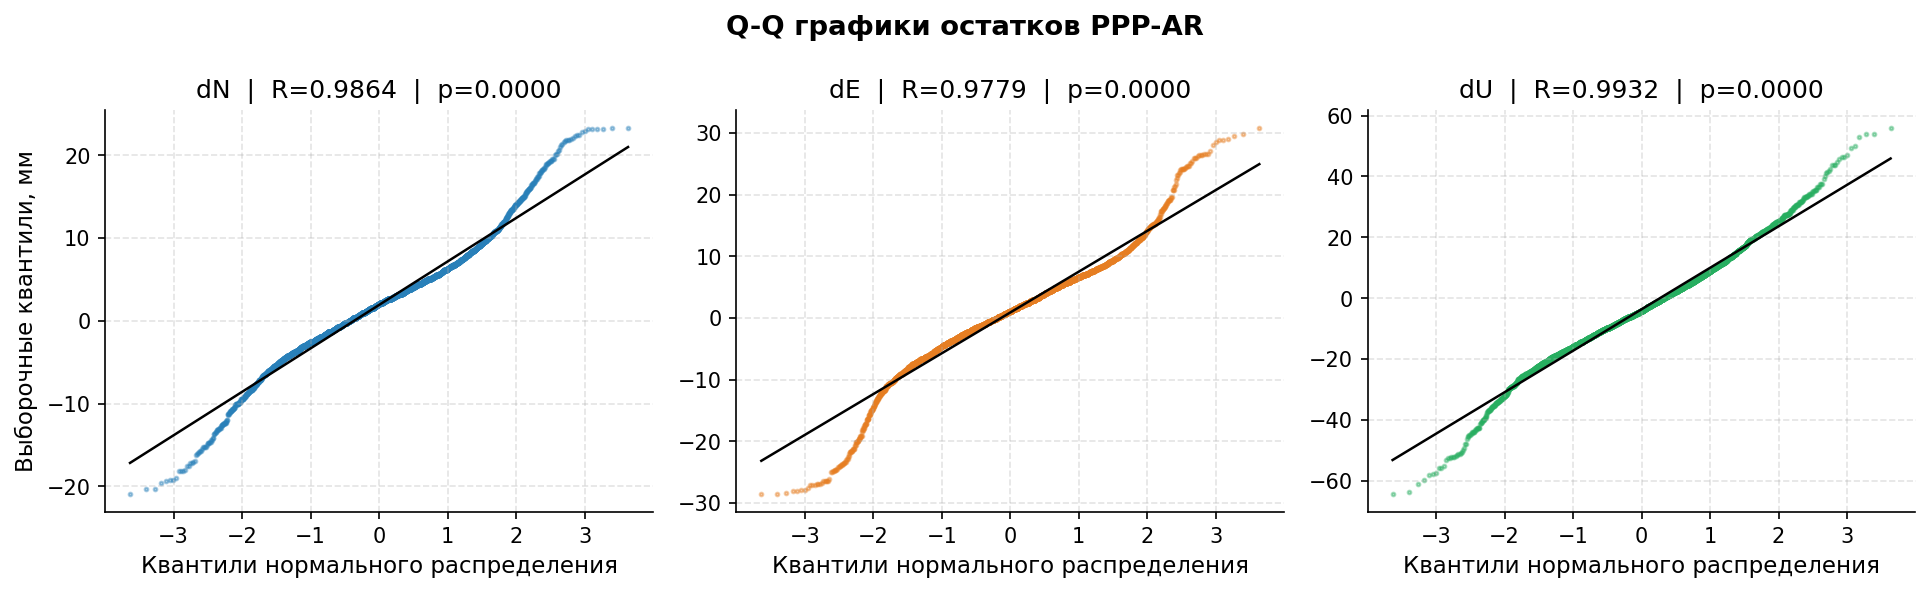

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Q-Q графики остатков PPP-AR', fontweight='bold')

for ax, col, lbl, clr in zip(axes,
        ['dN_m','dE_m','dU_m'], ['dN','dE','dU'],
        [CLR['N'], CLR['E'], CLR['U']]):
    vals = df[col].values * 1000
    sample = vals if len(vals)<=5000 else np.random.choice(vals, 5000, replace=False)
    (osm, osr), (slope, intercept, r) = sp_stats.probplot(sample, dist='norm')
    ax.scatter(osm, osr, s=3, color=clr, alpha=0.4, rasterized=True)
    ax.plot(osm, slope*np.array(osm)+intercept, 'k-', lw=1.2)
    _, p = sp_stats.shapiro(sample)
    ax.set_xlabel('Квантили нормального распределения')
    ax.set_ylabel('Выборочные квантили, мм' if ax is axes[0] else '')
    ax.set_title(f'{lbl}  |  R={r:.4f}  |  p={p:.4f}')

plt.tight_layout()
savefig('02_qqplot')
plt.show()

---
## 4. Доля фиксированных решений

  → fig_igs_03_fix_rate.png


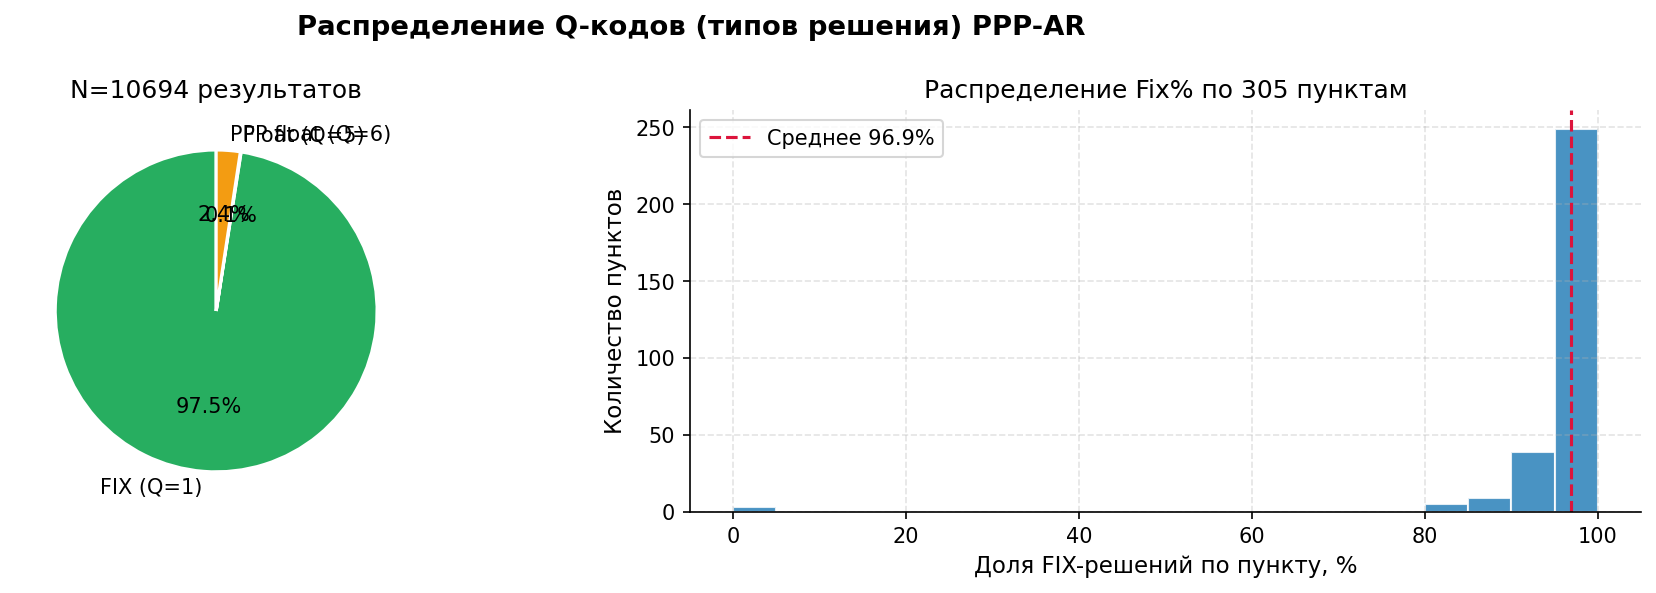

Глобальный Fix%         : 87.99%
Среднее Fix% по пунктам : 96.93% ± 10.23%
Медиана Fix% по пунктам : 100.00%
Пунктов с Fix%=100      : 195
Пунктов с Fix%<50       : 3


In [7]:
q_counts = df_ok['q'].value_counts().sort_index()
q_labels = {1:'FIX (Q=1)', 2:'DGPS (Q=2)', 5:'Float (Q=5)', 6:'PPP float (Q=6)'}
fix_by_st = df_ok.groupby('station').apply(
    lambda g: 100.0*g['q'].isin(FIX_Q_VALUES).sum()/len(g)).values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Распределение Q-кодов (типов решения) PPP-AR', fontweight='bold')

ax = axes[0]
lbls_q = [q_labels.get(int(k), f'Q={k}') for k in q_counts.index]
wedges, texts, autotexts = ax.pie(
    q_counts.values, labels=lbls_q,
    colors=['#27ae60','#3498db','#f39c12','#e74c3c'][:len(q_counts)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts: at.set_fontsize(10)
ax.set_title(f'N={N_ok} результатов')

ax2 = axes[1]
ax2.hist(fix_by_st, bins=np.arange(0,105,5), color='#2980b9', edgecolor='white', alpha=0.85)
ax2.axvline(fix_by_st.mean(), color='crimson', lw=1.5, ls='--',
            label=f'Среднее {fix_by_st.mean():.1f}%')
ax2.set_xlabel('Доля FIX-решений по пункту, %')
ax2.set_ylabel('Количество пунктов')
ax2.set_title(f'Распределение Fix% по {df_ok["station"].nunique()} пунктам')
ax2.legend()

plt.tight_layout()
savefig('03_fix_rate')
plt.show()

print(f'Глобальный Fix%         : {100*len(df_fix)/N_ok:.2f}%')
print(f'Среднее Fix% по пунктам : {fix_by_st.mean():.2f}% ± {fix_by_st.std():.2f}%')
print(f'Медиана Fix% по пунктам : {np.median(fix_by_st):.2f}%')
print(f'Пунктов с Fix%=100      : {(fix_by_st==100).sum()}')
print(f'Пунктов с Fix%<50       : {(fix_by_st<50).sum()}')

---
## 5. Box-plot: FIX против Float PPP

  → fig_igs_04_boxplot_fix_vs_float.png


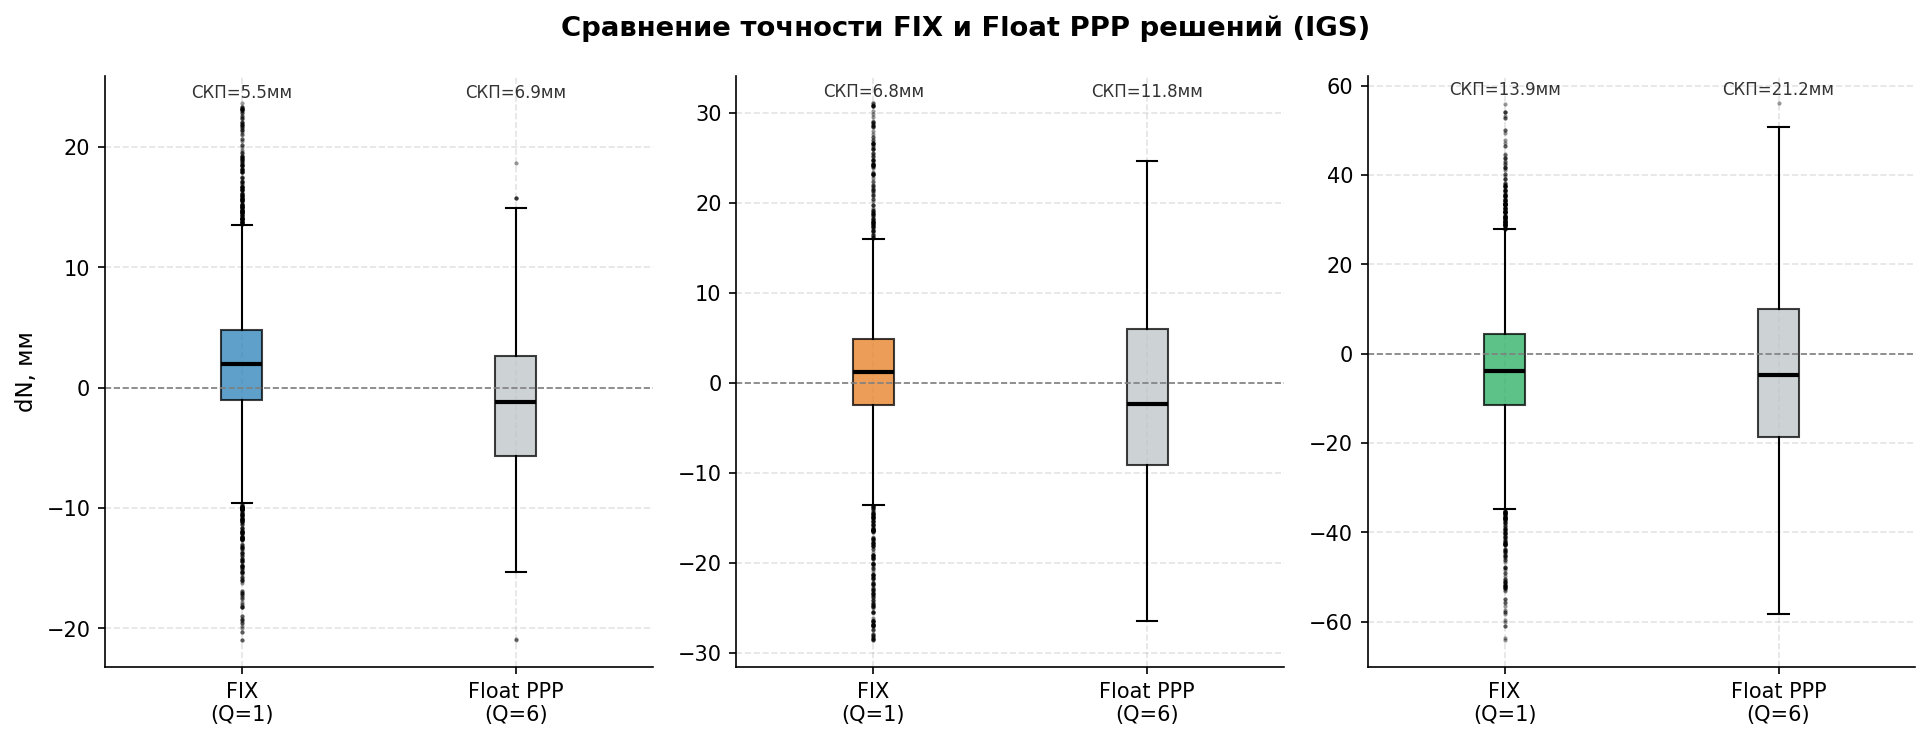

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Сравнение точности FIX и Float PPP решений (IGS)', fontweight='bold')

for ax, col, lbl, clr in zip(axes,
        ['dN_m','dE_m','dU_m'], ['dN, мм','dE, мм','dU, мм'],
        [CLR['N'], CLR['E'], CLR['U']]):
    data_fix   = df_fix[col].values   * 1000
    data_float = df_float[col].values * 1000
    groups = [data_fix, data_float] if len(data_float) else [data_fix]
    lbls   = ['FIX\n(Q=1)', 'Float PPP\n(Q=6)'] if len(data_float) else ['FIX\n(Q=1)']
    bp = ax.boxplot(groups, labels=lbls, patch_artist=True,
                    medianprops={'color':'black','linewidth':2},
                    flierprops={'marker':'.','markersize':2,'alpha':0.4})
    for patch, c in zip(bp['boxes'], [clr, '#bdc3c7']):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_ylabel(lbl if ax is axes[0] else '')
    ylim = ax.get_ylim()
    for i, grp in enumerate(groups):
        r = rms(grp/1000)*1000
        ax.text(i+1, ylim[1]*0.93,
                f'СКП={r:.1f}мм', ha='center', fontsize=8, color='#333')

plt.tight_layout()
savefig('04_boxplot_fix_vs_float')
plt.show()

---
## 6. Временной ряд точности (по дням)

  → fig_igs_05_daily_rms.png


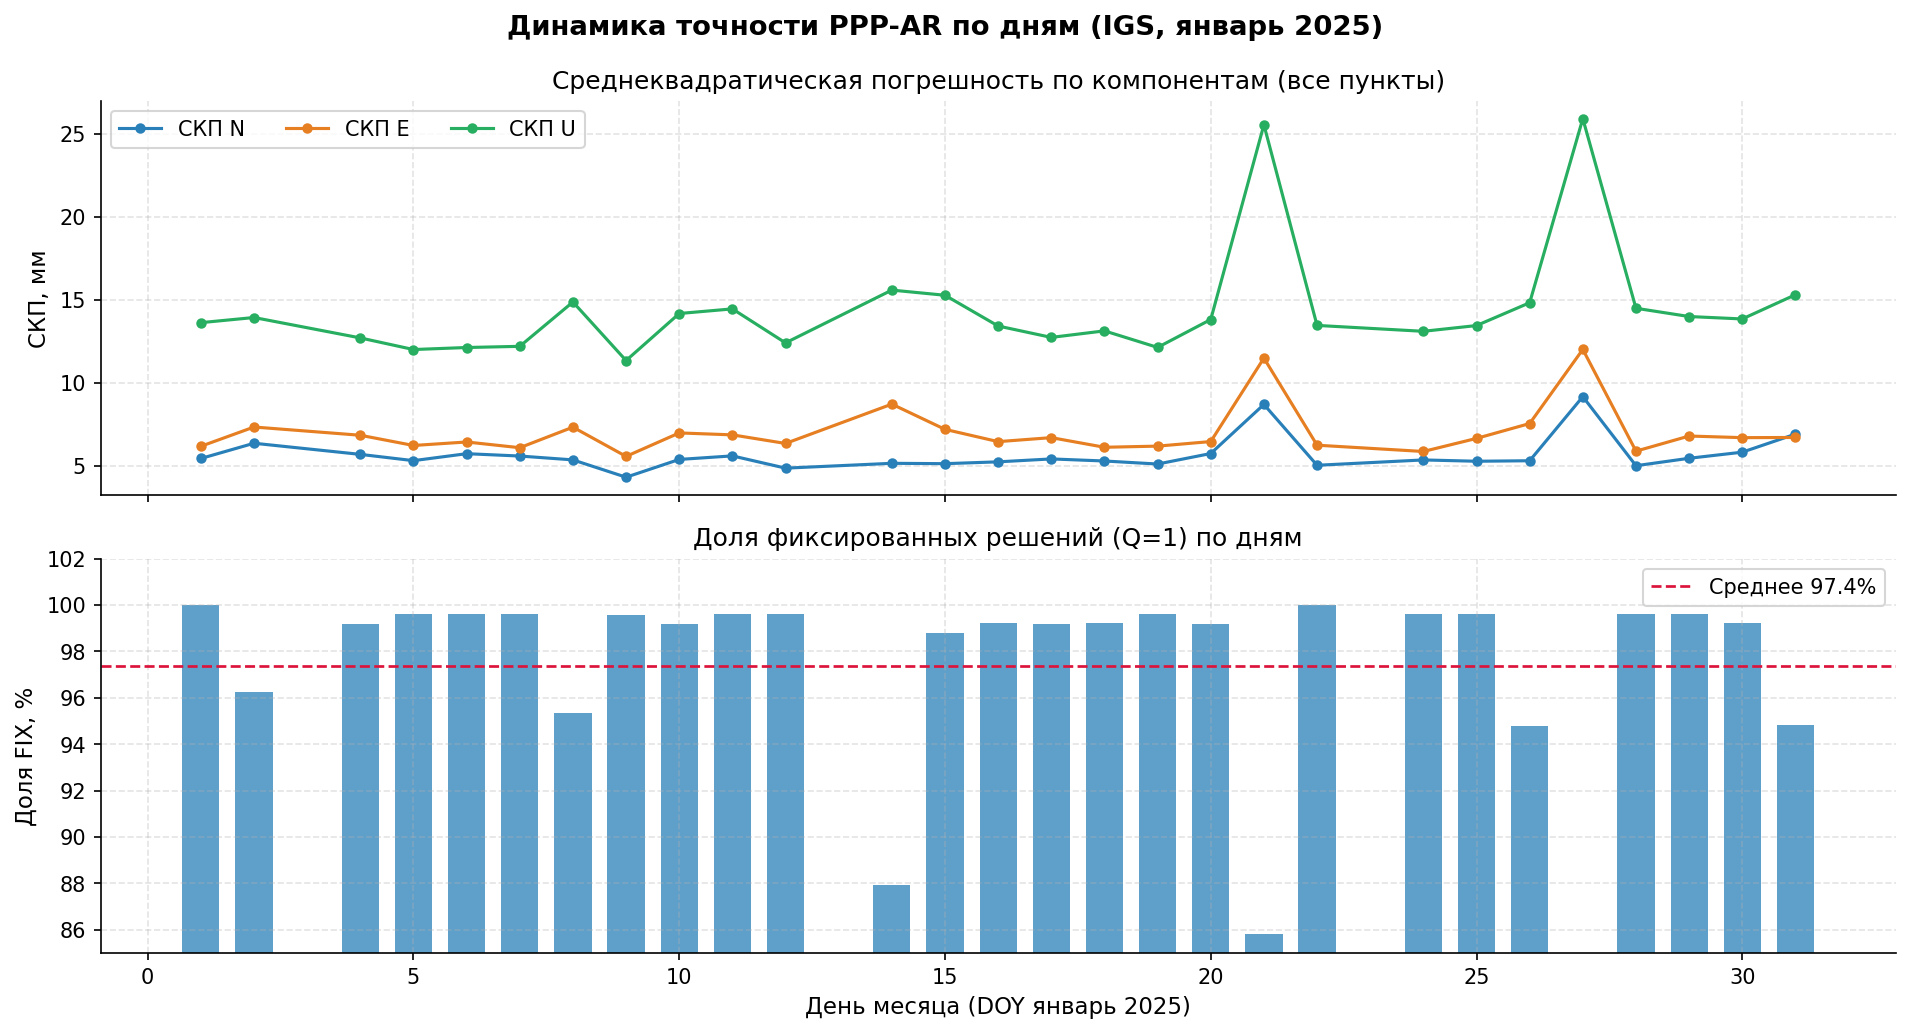

Суточная статистика:


,doy,rms_N,rms_E,rms_U,fix_pct,n_obs
0,1,5.45,6.19,13.63,100.00,236.0
1,2,6.37,7.35,13.94,96.26,428.0
2,4,5.70,6.85,12.71,99.20,502.0
3,5,5.32,6.24,12.01,99.61,512.0
4,6,5.74,6.45,12.13,99.61,518.0
5,7,5.60,6.10,12.20,99.61,508.0
6,8,5.37,7.34,14.87,95.34,472.0
7,9,4.33,5.58,11.35,99.59,490.0
8,10,5.40,6.99,14.18,99.18,486.0
9,11,5.61,6.88,14.46,99.60,494.0


In [9]:
daily = df.groupby('doy').apply(lambda g: pd.Series({
    'rms_N':   rms(g['dN_m'])*1000,
    'rms_E':   rms(g['dE_m'])*1000,
    'rms_U':   rms(g['dU_m'])*1000,
    'fix_pct': 100.0*g['q'].isin(FIX_Q_VALUES).sum()/len(g),
    'n_obs':   len(g),
})).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle('Динамика точности PPP-AR по дням (IGS, январь 2025)', fontweight='bold')

ax = axes[0]
for comp, clr, lbl in [('rms_N',CLR['N'],'СКП N'),
                        ('rms_E',CLR['E'],'СКП E'),
                        ('rms_U',CLR['U'],'СКП U')]:
    ax.plot(daily['doy'], daily[comp], marker='o', ms=4, lw=1.5,
            color=clr, label=lbl)
ax.set_ylabel('СКП, мм')
ax.legend(ncol=3)
ax.set_title('Среднеквадратическая погрешность по компонентам (все пункты)')

ax2 = axes[1]
ax2.bar(daily['doy'], daily['fix_pct'], color='#2980b9', alpha=0.75, width=0.7)
ax2.axhline(daily['fix_pct'].mean(), color='crimson', lw=1.3, ls='--',
            label=f'Среднее {daily["fix_pct"].mean():.1f}%')
ax2.set_ylim(85, 102)
ax2.set_xlabel('День месяца (DOY январь 2025)')
ax2.set_ylabel('Доля FIX, %')
ax2.set_title('Доля фиксированных решений (Q=1) по дням')
ax2.legend()

plt.tight_layout()
savefig('05_daily_rms')
plt.show()

print('Суточная статистика:')
display(daily.round(2))

---
## 7. СКП по пунктам

In [10]:
# Вычисление статистики по каждому пункту
st_rows = []
for station, grp in df.groupby('station'):
    n = len(grp)
    st_rows.append({
        'station': station,
        'n': n,
        'lat': grp['lat'].mean(),
        'mu_N': grp['dN_m'].mean()*1000,
        'mu_E': grp['dE_m'].mean()*1000,
        'mu_U': grp['dU_m'].mean()*1000,
        'sig_N': grp['dN_m'].std(ddof=1)*1000 if n>1 else 0,
        'sig_E': grp['dE_m'].std(ddof=1)*1000 if n>1 else 0,
        'sig_U': grp['dU_m'].std(ddof=1)*1000 if n>1 else 0,
        'rms_N': rms(grp['dN_m'])*1000,
        'rms_E': rms(grp['dE_m'])*1000,
        'rms_U': rms(grp['dU_m'])*1000,
        'fix_pct': 100.0*grp['q'].isin(FIX_Q_VALUES).sum()/n,
    })
st = pd.DataFrame(st_rows).sort_values('station').reset_index(drop=True)

print(f'Пунктов: {len(st)}')
print('\nГлобальный СКП (все эпохи):')
for comp, key in [('dN_m','N'),('dE_m','E'),('dU_m','U')]:
    r = rms(df[comp])*1000
    lo, hi = ci_rms(df[comp].values)
    print(f'  СКП {key} = {r:.2f} мм   ДИ 95%: [{lo*1000:.2f} ; {hi*1000:.2f}] мм')
print('\nСредний СКП по пунктам:')
for col, lbl in [('rms_N','N'),('rms_E','E'),('rms_U','U')]:
    print(f'  СКП {lbl} = {st[col].mean():.2f} мм   (±{st[col].std():.2f} мм)')

Пунктов: 289



Глобальный СКП (все эпохи):
  СКП N = 5.57 мм   ДИ 95%: [5.50 ; 5.65] мм
  СКП E = 6.93 мм   ДИ 95%: [6.84 ; 7.03] мм
  СКП U = 14.07 мм   ДИ 95%: [13.88 ; 14.27] мм

Средний СКП по пунктам:
  СКП N = 5.17 мм   (±2.31 мм)
  СКП E = 6.44 мм   (±3.37 мм)
  СКП U = 13.11 мм   (±5.69 мм)


  → fig_igs_06_rms_by_station.png


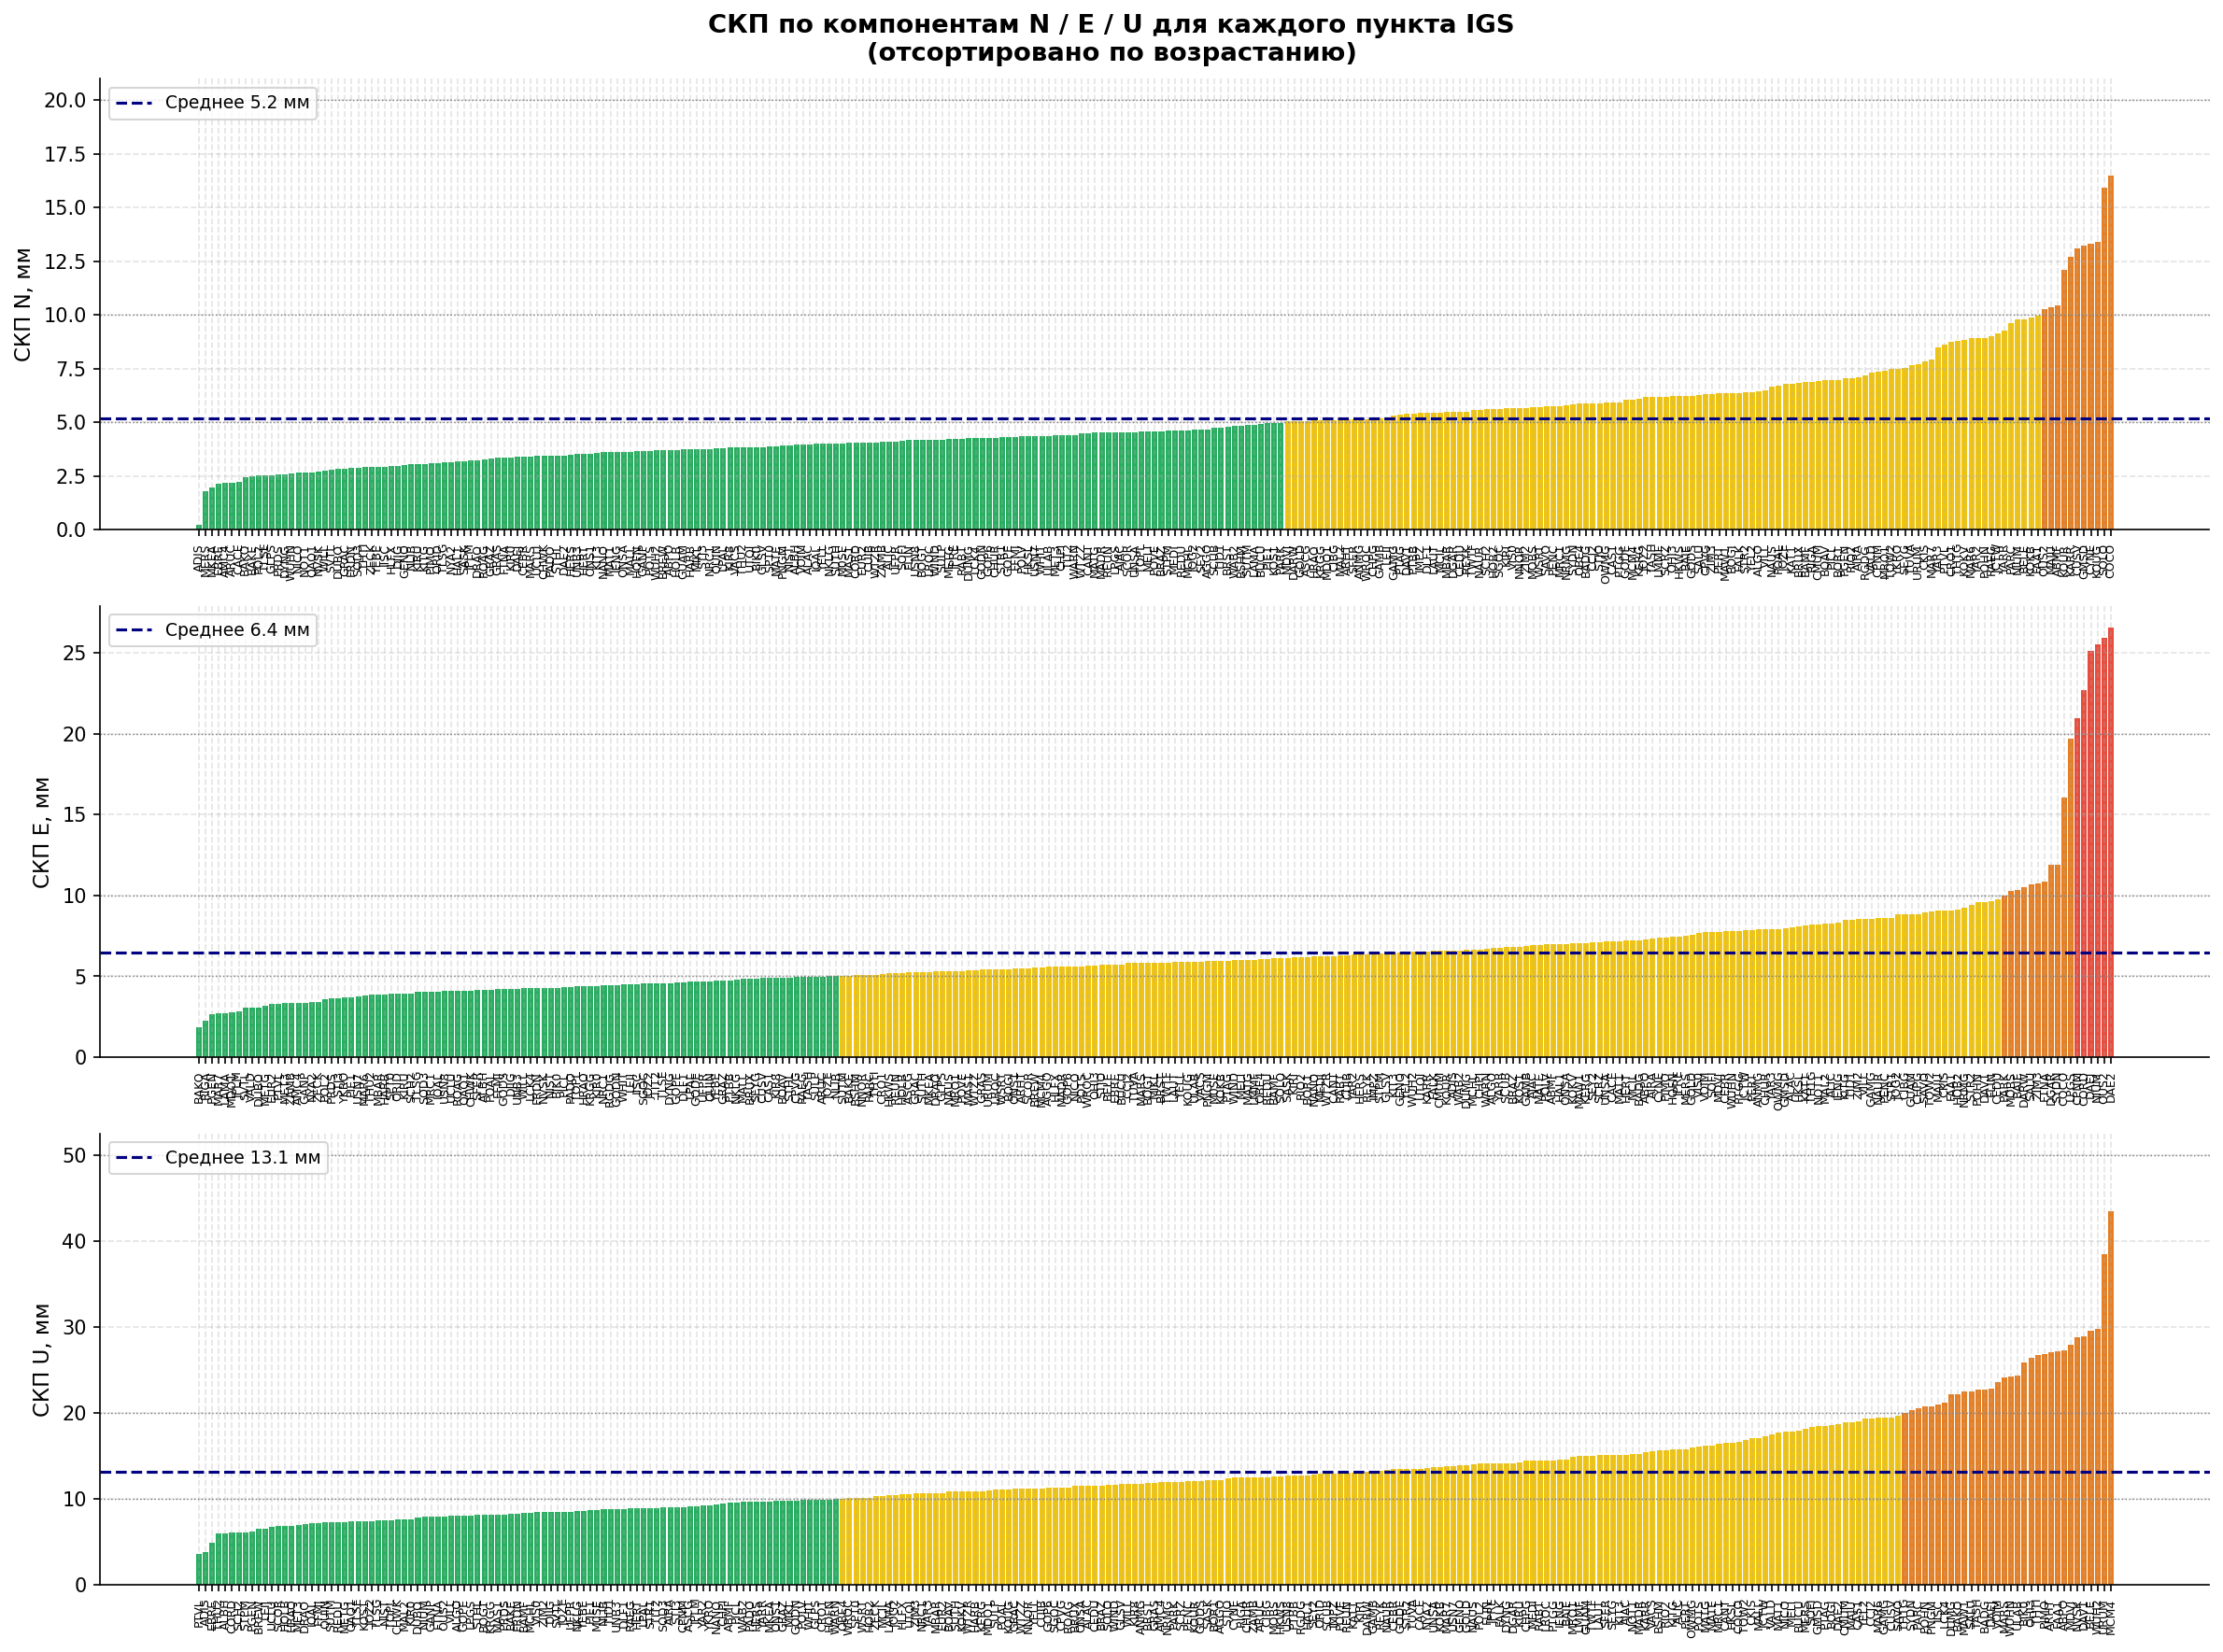

In [11]:
# Три сортированных графика СКП по пунктам (N, E, U)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('СКП по компонентам N / E / U для каждого пункта IGS\n(отсортировано по возрастанию)',
             fontweight='bold')

for ax, col, lbl, clr, thr in zip(axes,
        ['rms_N','rms_E','rms_U'],
        ['СКП N, мм','СКП E, мм','СКП U, мм'],
        [CLR['N'], CLR['E'], CLR['U']],
        [GRADE_THR_H, GRADE_THR_H, GRADE_THR_V]):
    data_s = st.sort_values(col)
    bar_clrs = [
        '#e74c3c' if v > thr[-1] else
        '#e67e22' if v > thr[-2] else
        '#f1c40f' if v > thr[0] else '#27ae60'
        for v in data_s[col]
    ]
    ax.bar(range(len(data_s)), data_s[col], color=bar_clrs, edgecolor='none', width=0.85)
    ax.axhline(st[col].mean(), color='navy', lw=1.5, ls='--',
               label=f'Среднее {st[col].mean():.1f} мм')
    for t in thr:
        ax.axhline(t, color='gray', lw=0.7, ls=':')
    ax.set_xticks(range(len(data_s)))
    ax.set_xticklabels(data_s['station'], rotation=90, fontsize=6)
    ax.set_ylabel(lbl)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
savefig('06_rms_by_station')
plt.show()

  → fig_igs_07_rms_boxplot_vs_lat.png


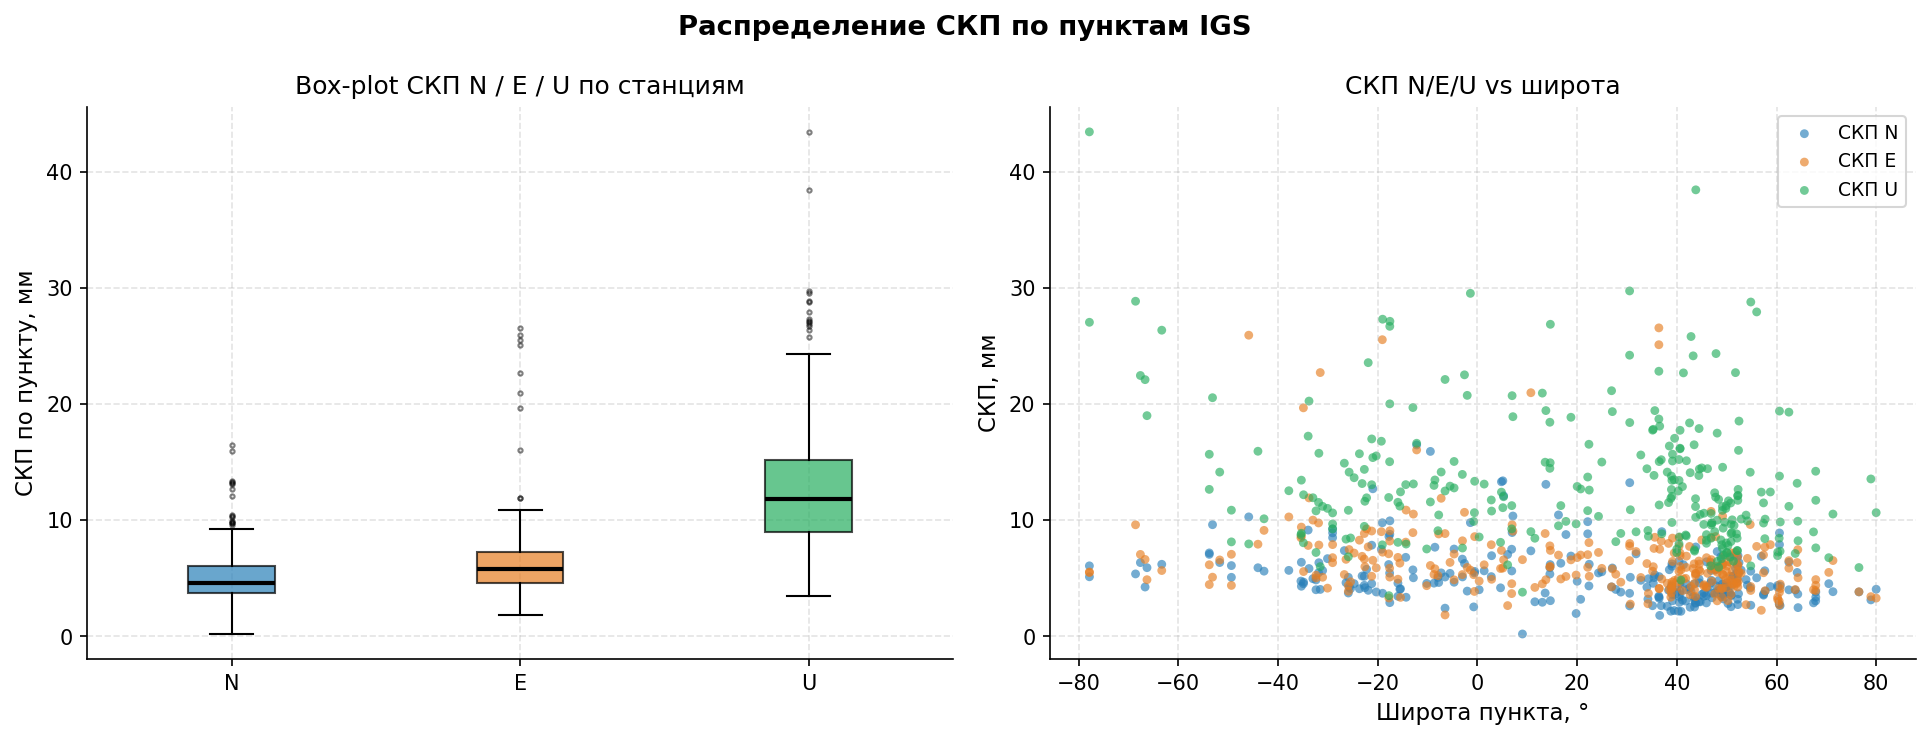

In [12]:
# Box-plot СКП N/E/U по всем пунктам + СКП vs широта
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Распределение СКП по пунктам IGS', fontweight='bold')

ax = axes[0]
bp = ax.boxplot([st['rms_N'], st['rms_E'], st['rms_U']],
                labels=['N','E','U'], patch_artist=True,
                medianprops={'color':'black','linewidth':2},
                flierprops={'marker':'.','markersize':4,'alpha':0.5})
for patch, clr in zip(bp['boxes'], [CLR['N'],CLR['E'],CLR['U']]):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
ax.set_ylabel('СКП по пункту, мм')
ax.set_title('Box-plot СКП N / E / U по станциям')

ax2 = axes[1]
for col, clr, lbl in [('rms_N',CLR['N'],'N'),('rms_E',CLR['E'],'E'),('rms_U',CLR['U'],'U')]:
    ax2.scatter(st['lat'], st[col], c=clr, s=18, alpha=0.65, label=f'СКП {lbl}', edgecolors='none')
ax2.set_xlabel('Широта пункта, °')
ax2.set_ylabel('СКП, мм')
ax2.set_title('СКП N/E/U vs широта')
ax2.legend(fontsize=9)

plt.tight_layout()
savefig('07_rms_boxplot_vs_lat')
plt.show()

---
## 8. Классы точности по каждой компоненте

  → fig_igs_08_accuracy_grades.png


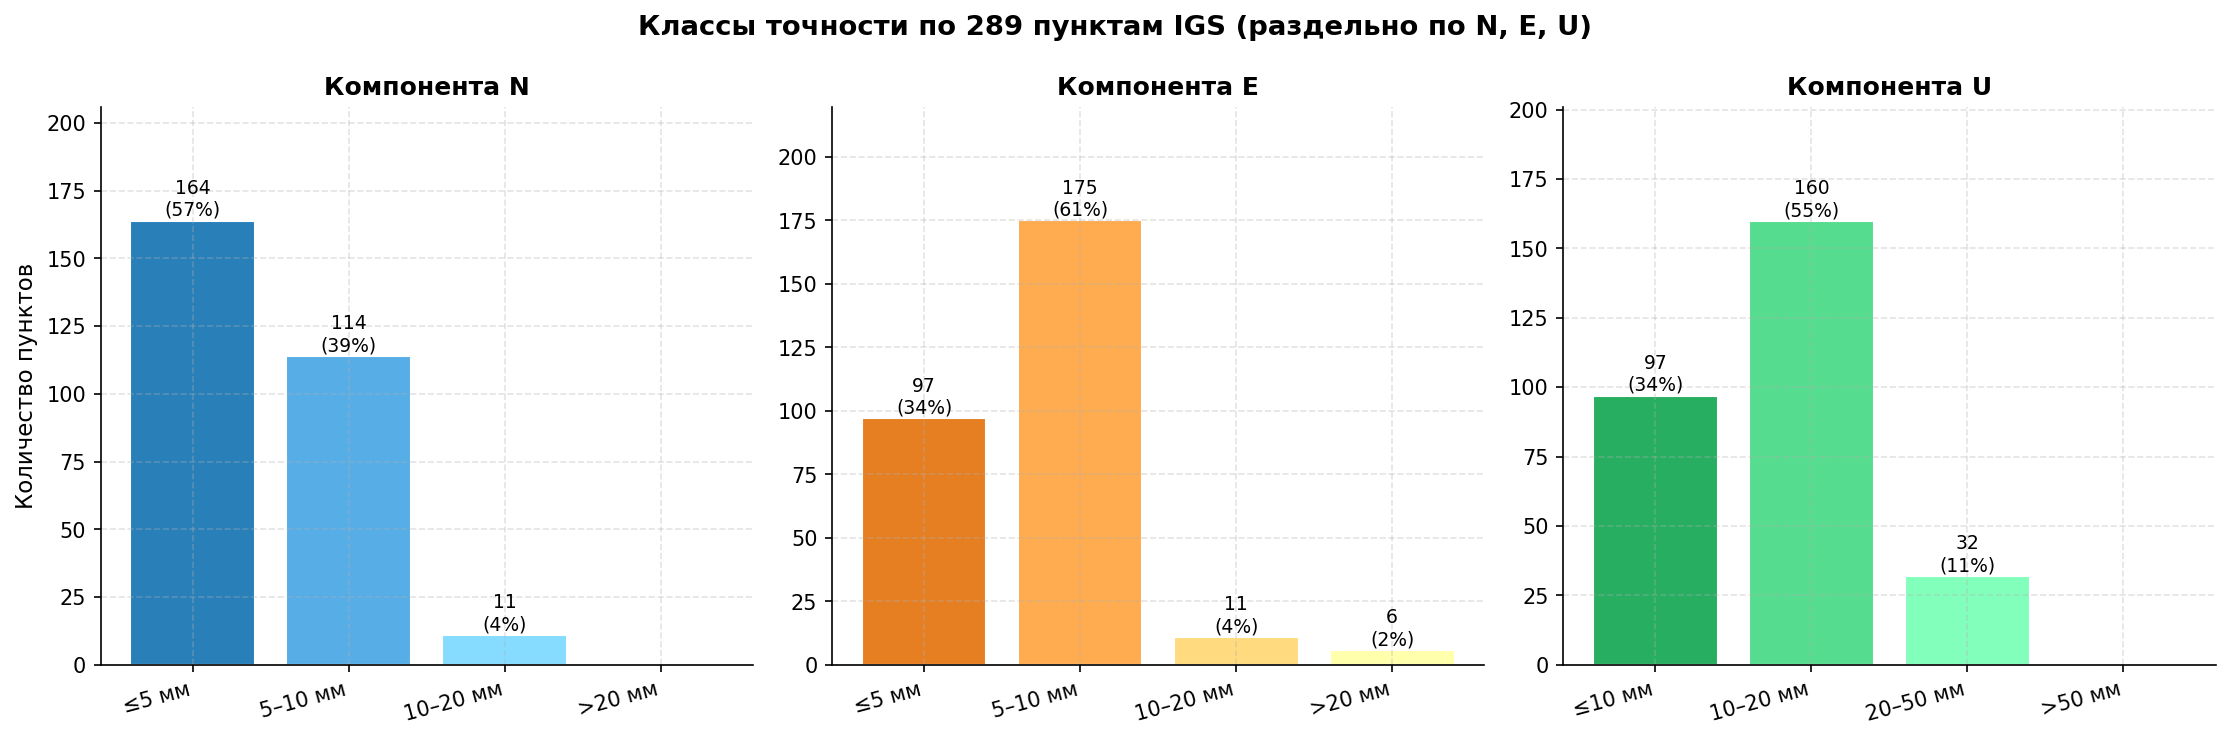


Классы точности по компонентам:
  N:
    ≤5 мм       :  164 пунктов ( 56.7%)
    5–10 мм     :  114 пунктов ( 39.4%)
    10–20 мм    :   11 пунктов (  3.8%)
    >20 мм      :    0 пунктов (  0.0%)
  E:
    ≤5 мм       :   97 пунктов ( 33.6%)
    5–10 мм     :  175 пунктов ( 60.6%)
    10–20 мм    :   11 пунктов (  3.8%)
    >20 мм      :    6 пунктов (  2.1%)
  U:
    ≤10 мм      :   97 пунктов ( 33.6%)
    10–20 мм    :  160 пунктов ( 55.4%)
    20–50 мм    :   32 пунктов ( 11.1%)
    >50 мм      :    0 пунктов (  0.0%)


In [13]:
# Для N и E — одни пороги, для U — свои
grade_cfg = [
    ('rms_N', 'N', GRADE_THR_H, GRADE_LABELS_H, CLR['N']),
    ('rms_E', 'E', GRADE_THR_H, GRADE_LABELS_H, CLR['E']),
    ('rms_U', 'U', GRADE_THR_V, GRADE_LABELS_V, CLR['U']),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Классы точности по {len(st)} пунктам IGS (раздельно по N, E, U)',
             fontweight='bold')

for ax, (col, comp, thrs, lbls, clr) in zip(axes, grade_cfg):
    gdata = grade_counts(st[col].values, thrs, lbls)
    cnts = [g[1] for g in gdata]
    pcts = [g[2] for g in gdata]
    # Оттенки одного цвета
    import matplotlib.colors as mcolors
    base = mcolors.to_rgb(clr)
    shades = [tuple(min(1, c + i*0.18) for c in base) for i in range(len(cnts))]
    bars = ax.bar(lbls, cnts, color=shades, edgecolor='white')
    for bar, cnt, pct in zip(bars, cnts, pcts):
        if cnt:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{cnt}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Компонента {comp}', fontweight='bold')
    ax.set_ylabel('Количество пунктов' if ax is axes[0] else '')
    ax.set_xticklabels(lbls, rotation=15, ha='right')
    ax.set_ylim(0, max(cnts)*1.25 + 1)

plt.tight_layout()
savefig('08_accuracy_grades')
plt.show()

print('\nКлассы точности по компонентам:')
for col, comp, thrs, lbls, _ in grade_cfg:
    print(f'  {comp}:')
    for lbl, cnt, pct in grade_counts(st[col].values, thrs, lbls):
        print(f'    {lbl:<12s}: {cnt:4d} пунктов ({pct:5.1f}%)')

---
## 9. Кумулятивные функции распределения СКП

  → fig_igs_09_cdf.png


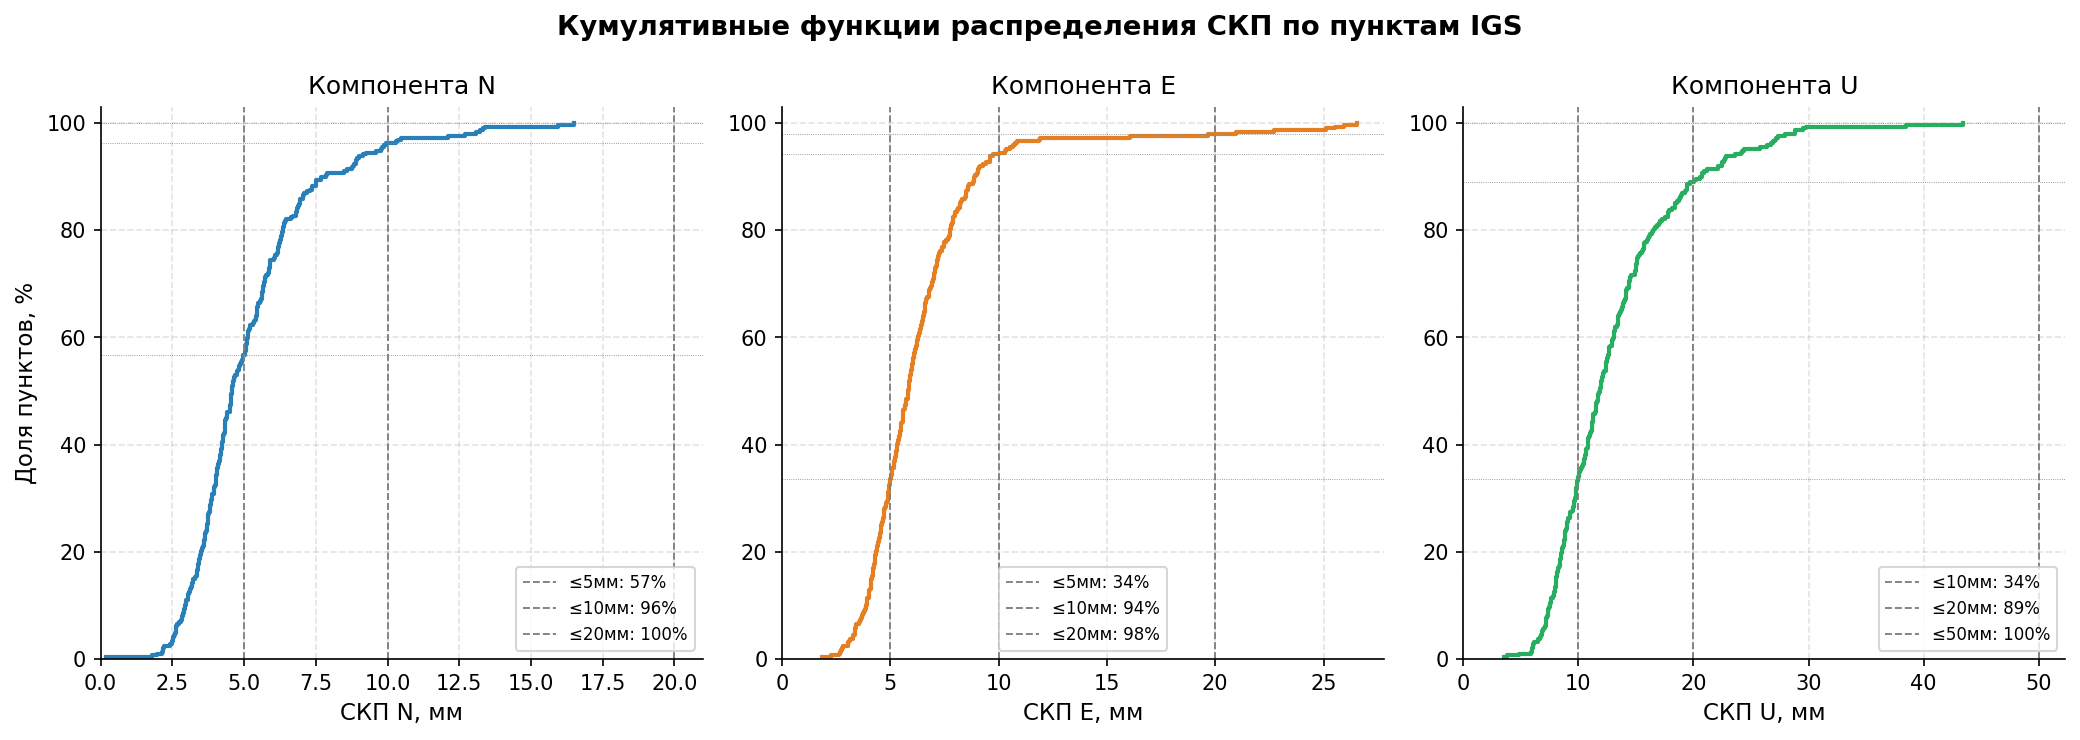

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Кумулятивные функции распределения СКП по пунктам IGS', fontweight='bold')

for ax, col, comp, clr, thrs in zip(axes,
        ['rms_N','rms_E','rms_U'],
        ['N','E','U'],
        [CLR['N'],CLR['E'],CLR['U']],
        [GRADE_THR_H, GRADE_THR_H, GRADE_THR_V]):
    sorted_v = np.sort(st[col].values)
    cdf = np.arange(1, len(sorted_v)+1) / len(sorted_v) * 100
    ax.step(sorted_v, cdf, where='post', lw=2, color=clr)
    for thr in thrs:
        pct = 100.0*(sorted_v <= thr).sum()/len(sorted_v)
        ax.axvline(thr, color='gray', lw=0.9, ls='--',
                   label=f'≤{thr}мм: {pct:.0f}%')
        ax.axhline(pct, color='gray', lw=0.4, ls=':')
    ax.set_xlabel(f'СКП {comp}, мм')
    ax.set_ylabel('Доля пунктов, %' if ax is axes[0] else '')
    ax.set_title(f'Компонента {comp}')
    ax.set_xlim(left=0)
    ax.set_ylim(0, 103)
    ax.legend(fontsize=8)

plt.tight_layout()
savefig('09_cdf')
plt.show()

---
## 10. Сводная таблица СКП по пунктам

In [15]:
from IPython.display import HTML

def comp_bg(v, thrs):
    if v <= thrs[0]: return '#d5f5e3'
    if v <= thrs[1]: return '#fef9e7'
    if v <= thrs[2]: return '#fdebd0'
    return '#fadbd8'

def fix_bg(v):
    if v >= 99: return '#d5f5e3'
    if v >= 90: return '#fef9e7'
    if v >= 70: return '#fdebd0'
    return '#fadbd8'

cols_h = ['Пункт','N эпох','μN','μE','μU','σN','σE','σU',
          'СКП N','СКП E','СКП U','Fix%']
units  = ['','','мм','мм','мм','мм','мм','мм','мм','мм','мм','%']

hdr = ''.join(
    f'<th style="background:#2c3e50;color:white;padding:4px 8px;white-space:nowrap">{c}<br><span style="font-weight:normal;font-size:10px">{u}</span></th>'
    for c, u in zip(cols_h, units)
)

rows_html = []
for _, row in st.iterrows():
    def td(v, fmt='.2f', bg=None):
        s = 'padding:3px 7px;text-align:center'
        if bg: s += f';background:{bg}'
        return f'<td style="{s}">{v:{fmt}}</td>'
    bgN = comp_bg(row['rms_N'], GRADE_THR_H + [999])
    bgE = comp_bg(row['rms_E'], GRADE_THR_H + [999])
    bgU = comp_bg(row['rms_U'], GRADE_THR_V + [999])
    bgF = fix_bg(row['fix_pct'])
    cells  = f'<td style="padding:3px 7px;font-family:monospace">{row["station"]}</td>'
    cells += td(int(row['n']),'d')
    cells += td(row['mu_N']) + td(row['mu_E']) + td(row['mu_U'])
    cells += td(row['sig_N']) + td(row['sig_E']) + td(row['sig_U'])
    cells += f'<td style="padding:3px 7px;text-align:center;background:{bgN}">{row["rms_N"]:.2f}</td>'
    cells += f'<td style="padding:3px 7px;text-align:center;background:{bgE}">{row["rms_E"]:.2f}</td>'
    cells += f'<td style="padding:3px 7px;text-align:center;background:{bgU}">{row["rms_U"]:.2f}</td>'
    cells += f'<td style="padding:3px 7px;text-align:center;background:{bgF}">{row["fix_pct"]:.1f}%</td>'
    rows_html.append(f'<tr>{cells}</tr>')

legend = ('<span style="background:#d5f5e3;padding:2px 5px">N/E ≤5мм, U ≤10мм</span> '
          '<span style="background:#fef9e7;padding:2px 5px">N/E ≤10мм, U ≤20мм</span> '
          '<span style="background:#fdebd0;padding:2px 5px">N/E ≤20мм, U ≤50мм</span> '
          '<span style="background:#fadbd8;padding:2px 5px">хуже</span>')

html = f'''<h3>IGS — СКП по пунктам ({len(st)} пунктов)</h3>
<p style="font-size:11px">μ — смещение, σ — СКО, СКП — среднеквадратическая погрешность. Цвет: {legend}</p>
<div style="max-height:520px;overflow-y:auto">
<table style="border-collapse:collapse;font-size:12px">
  <thead><tr>{hdr}</tr></thead>
  <tbody>{''.join(rows_html)}</tbody>
</table></div>'''

display(HTML(html))

Пункт,N эпох,μNмм,μEмм,μUмм,σNмм,σEмм,σUмм,СКП Nмм,СКП Eмм,СКП Uмм,Fix%%
ABMF,33,8.67,-3.41,-3.40,5.93,6.20,9.03,10.45,6.99,9.52,100.0%
ABPO,15,-0.73,-0.70,-21.35,3.76,7.46,17.63,3.71,7.24,27.31,100.0%
ADIS,1,-0.20,6.60,-3.80,0.00,0.00,0.00,0.20,6.60,3.80,100.0%
AGGO,37,-0.45,1.37,6.25,4.71,5.48,10.61,4.67,5.58,12.19,94.6%
AIRA,1,7.10,-7.30,-9.00,0.00,0.00,0.00,7.10,7.30,9.00,100.0%
AJAC,38,3.33,4.73,-13.27,3.11,5.09,7.35,4.53,6.90,15.12,97.4%
ALAC,37,0.58,6.03,-6.25,3.98,5.34,9.81,3.97,8.00,11.52,100.0%
ALBH,37,2.65,-2.80,-0.60,2.97,3.09,6.00,3.95,4.14,5.95,100.0%
ALGO,38,5.58,5.46,-5.04,3.21,4.06,6.31,6.42,6.77,8.01,100.0%
ALIC,38,0.71,-1.34,12.30,4.09,8.28,9.93,4.10,8.28,15.72,94.7%


---
## 11. Итоговая таблица для статьи

In [16]:
result_rows = []
for subset_lbl, subset in [('Все решения', df), ('FIX (Q=1)', df_fix), ('Float PPP (Q=6)', df_float)]:
    if len(subset) == 0: continue
    row = {'Тип решения': subset_lbl, 'N эпох': len(subset)}
    for comp, key in [('dN_m','N'),('dE_m','E'),('dU_m','U')]:
        vals = subset[comp].values
        lo, hi = ci_rms(vals)
        row[f'μ {key}, мм'] = f'{np.mean(vals)*1000:.2f}'
        row[f'σ {key}, мм'] = f'{np.std(vals,ddof=1)*1000:.2f}'
        row[f'СКП {key}, мм'] = f'{rms(vals)*1000:.2f}'
        row[f'ДИ 95% {key}'] = f'[{lo*1000:.2f};{hi*1000:.2f}]'
    result_rows.append(row)

df_res = pd.DataFrame(result_rows).set_index('Тип решения')
print('=== Итоговая таблица точности PPP-AR (IGS, январь 2025) ===')
display(df_res)

print('\n=== Сводка ===')
for col, lbl, thrs in [('rms_N','N',GRADE_THR_H),('rms_E','E',GRADE_THR_H),('rms_U','U',GRADE_THR_V)]:
    r_glob = rms(df[{'rms_N':'dN_m','rms_E':'dE_m','rms_U':'dU_m'}[col]].values)*1000
    r_mean = st[col].mean()
    t1 = thrs[0]; t2 = thrs[1]
    pct1 = 100*(st[col]<=t1).mean(); pct2 = 100*(st[col]<=t2).mean()
    print(f'  {lbl}: СКП глоб.={r_glob:.2f}мм  ср.по пунктам={r_mean:.2f}мм  '
          f'≤{t1}мм: {pct1:.0f}%  ≤{t2}мм: {pct2:.0f}%')
print(f'  Fix% (глобально)={100*len(df_fix)/len(df):.1f}%  '
      f'Fix% (ср. по пунктам)={fix_by_st.mean():.1f}%')

=== Итоговая таблица точности PPP-AR (IGS, январь 2025) ===


,N эпох,"μ N, мм","σ N, мм","СКП N, мм",ДИ 95% N,"μ E, мм","σ E, мм","СКП E, мм",ДИ 95% E,"μ U, мм","σ U, мм","СКП U, мм",ДИ 95% U
Тип решения,,,,,,,,,,,,,
Все решения,9617,1.88,5.25,5.57,[5.50;5.65],0.94,6.87,6.93,[6.84;7.03],-3.50,13.63,14.07,[13.88;14.27]
FIX (Q=1),9410,1.95,5.19,5.54,[5.46;5.62],1.01,6.71,6.79,[6.69;6.89],-3.48,13.43,13.88,[13.68;14.08]
Float PPP (Q=6),207,-1.42,6.75,6.88,[6.28;7.61],-2.04,11.62,11.77,[10.73;13.02],-4.65,20.71,21.18,[19.32;23.43]



=== Сводка ===
  N: СКП глоб.=5.57мм  ср.по пунктам=5.17мм  ≤5мм: 57%  ≤10мм: 96%
  E: СКП глоб.=6.93мм  ср.по пунктам=6.44мм  ≤5мм: 34%  ≤10мм: 94%
  U: СКП глоб.=14.07мм  ср.по пунктам=13.11мм  ≤10мм: 34%  ≤20мм: 89%
  Fix% (глобально)=97.8%  Fix% (ср. по пунктам)=96.9%


---
## 12. Анализ после исключения пунктов с СКП > 20 мм

Ряд пунктов демонстрирует СКП, существенно превышающую типичные значения. Для получения
характеристик точности, репрезентативных для стабильно работающих станций сети,
из выборки исключаются пункты, у которых хотя бы по одной компоненте СКП > 20 мм.

In [17]:
OUTLIER_THR_MM = 20.0   # порог по СКП для исключения пункта (мм)

# Пункты-выбросы: СКП хотя бы по одной компоненте > порога
mask_out_st = (
    (st['rms_N'] > OUTLIER_THR_MM) |
    (st['rms_E'] > OUTLIER_THR_MM) |
    (st['rms_U'] > OUTLIER_THR_MM)
)
st_out  = st[mask_out_st].sort_values('rms_U', ascending=False).reset_index(drop=True)
st_good = st[~mask_out_st].reset_index(drop=True)

print(f'Порог исключения: СКП > {OUTLIER_THR_MM:.0f} мм хотя бы по одной компоненте')
print(f'Исключено пунктов : {len(st_out)}  ({100*len(st_out)/len(st):.1f}%)')
print(f'Оставлено пунктов : {len(st_good)}  ({100*len(st_good)/len(st):.1f}%)')
print()

# Таблица исключённых пунктов
hdr2 = ''.join(
    f'<th style="background:#922b21;color:white;padding:4px 8px">{c}</th>'
    for c in ['Пункт','N эпох','СКП N, мм','СКП E, мм','СКП U, мм','Fix%','Причина']
)
rows2 = []
for _, row in st_out.iterrows():
    reasons = []
    if row['rms_N'] > OUTLIER_THR_MM: reasons.append(f'N={row["rms_N"]:.1f}мм')
    if row['rms_E'] > OUTLIER_THR_MM: reasons.append(f'E={row["rms_E"]:.1f}мм')
    if row['rms_U'] > OUTLIER_THR_MM: reasons.append(f'U={row["rms_U"]:.1f}мм')
    cells2  = f'<td style="padding:3px 8px;font-family:monospace;font-weight:bold">{row["station"]}</td>'
    cells2 += f'<td style="padding:3px 8px;text-align:center">{int(row["n"])}</td>'
    for comp, thr_col in [('rms_N', GRADE_THR_H), ('rms_E', GRADE_THR_H), ('rms_U', GRADE_THR_V)]:
        v = row[comp]
        bg = '#fadbd8' if v > OUTLIER_THR_MM else '#fdebd0'
        cells2 += f'<td style="padding:3px 8px;text-align:center;background:{bg};font-weight:{"bold" if v>OUTLIER_THR_MM else "normal"}">{v:.2f}</td>'
    cells2 += f'<td style="padding:3px 8px;text-align:center">{row["fix_pct"]:.1f}%</td>'
    cells2 += f'<td style="padding:3px 8px;color:#922b21">{", ".join(reasons)}</td>'
    rows2.append(f'<tr>{cells2}</tr>')

display(HTML(f'''<h4>Исключённые пункты (СКП &gt; {OUTLIER_THR_MM:.0f} мм)</h4>
<table style="border-collapse:collapse;font-size:12px">
  <thead><tr>{hdr2}</tr></thead>
  <tbody>{"".join(rows2)}</tbody>
</table>'''))

Порог исключения: СКП > 20 мм хотя бы по одной компоненте
Исключено пунктов : 37  (12.8%)
Оставлено пунктов : 252  (87.2%)



Пункт,N эпох,"СКП N, мм","СКП E, мм","СКП U, мм",Fix%,Причина
MCM4,34,6.07,5.53,43.45,100.0%,U=43.4мм
URUM,38,7.70,5.42,38.45,100.0%,U=38.5мм
WUH2,35,3.70,6.52,29.75,100.0%,U=29.7мм
BELE,39,9.79,5.71,29.54,100.0%,U=29.5мм
DAV1,17,5.37,9.60,28.86,100.0%,U=28.9мм
NVSK,36,2.68,4.28,28.79,100.0%,U=28.8мм
MDVJ,29,5.04,7.74,27.94,93.1%,U=27.9мм
ABPO,15,3.71,7.24,27.31,100.0%,U=27.3мм
FAA1,38,9.95,9.09,27.13,94.7%,U=27.1мм
ARHT,37,5.13,5.49,27.05,94.6%,U=27.0мм


=== Сравнение СКП до и после исключения пунктов с СКП > 20 мм (мм) ===


,μ N,σ N,СКП N,ДИ95 N,μ E,σ E,СКП E,ДИ95 E,μ U,σ U,СКП U,ДИ95 U,Fix%
Выборка,,,,,,,,,,,,,
Все пункты (n=289),1.88,5.25,5.57,[5.50;5.65],0.94,6.87,6.93,[6.84;7.03],-3.50,13.63,14.07,[13.88;14.27],97.8%
Без выбросов (n=252),1.93,5.16,5.51,[5.43;5.59],1.10,6.24,6.34,[6.24;6.43],-2.95,11.72,12.08,[11.91;12.27],98.3%


  → fig_igs_10_hist_clean.png


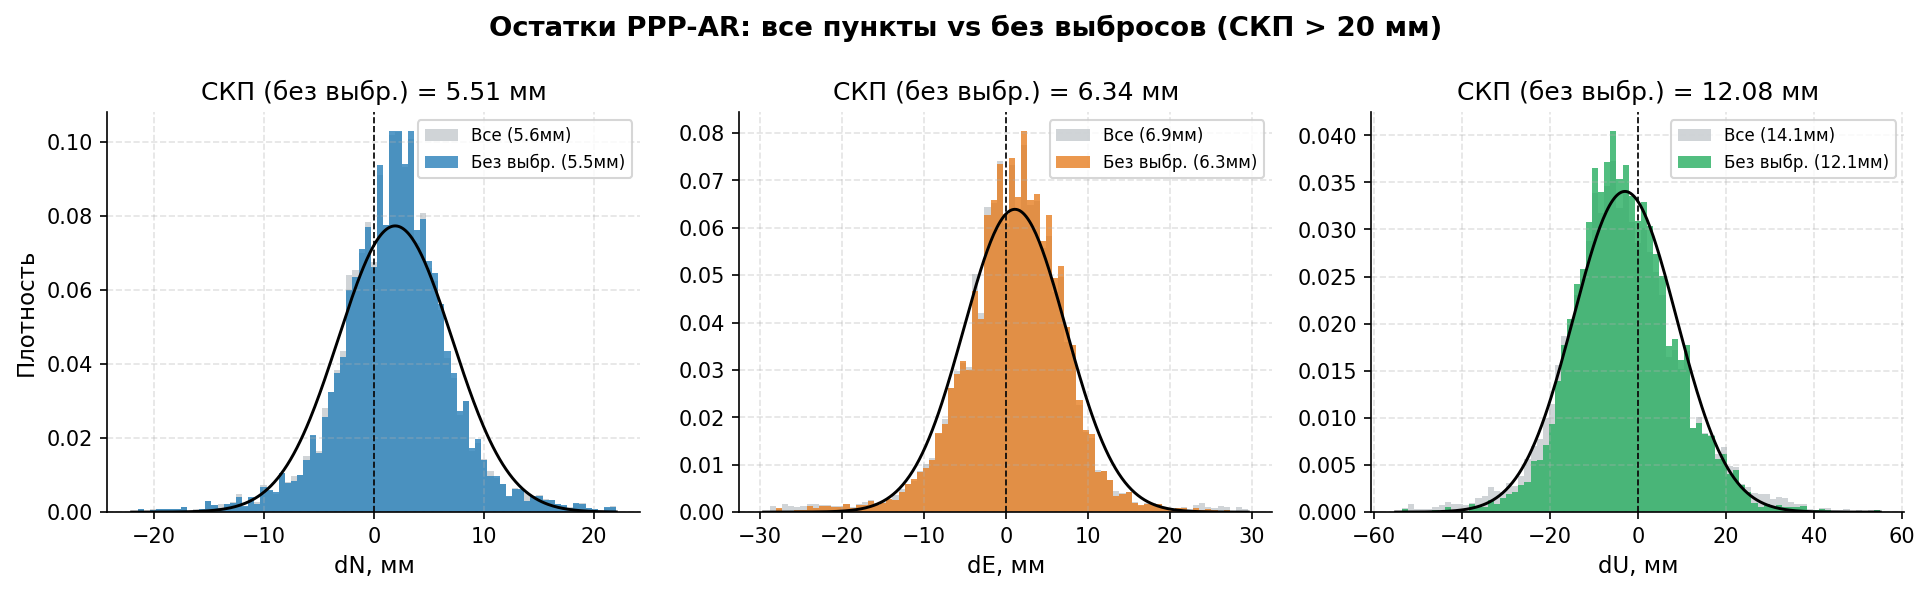

  → fig_igs_11_cdf_clean.png


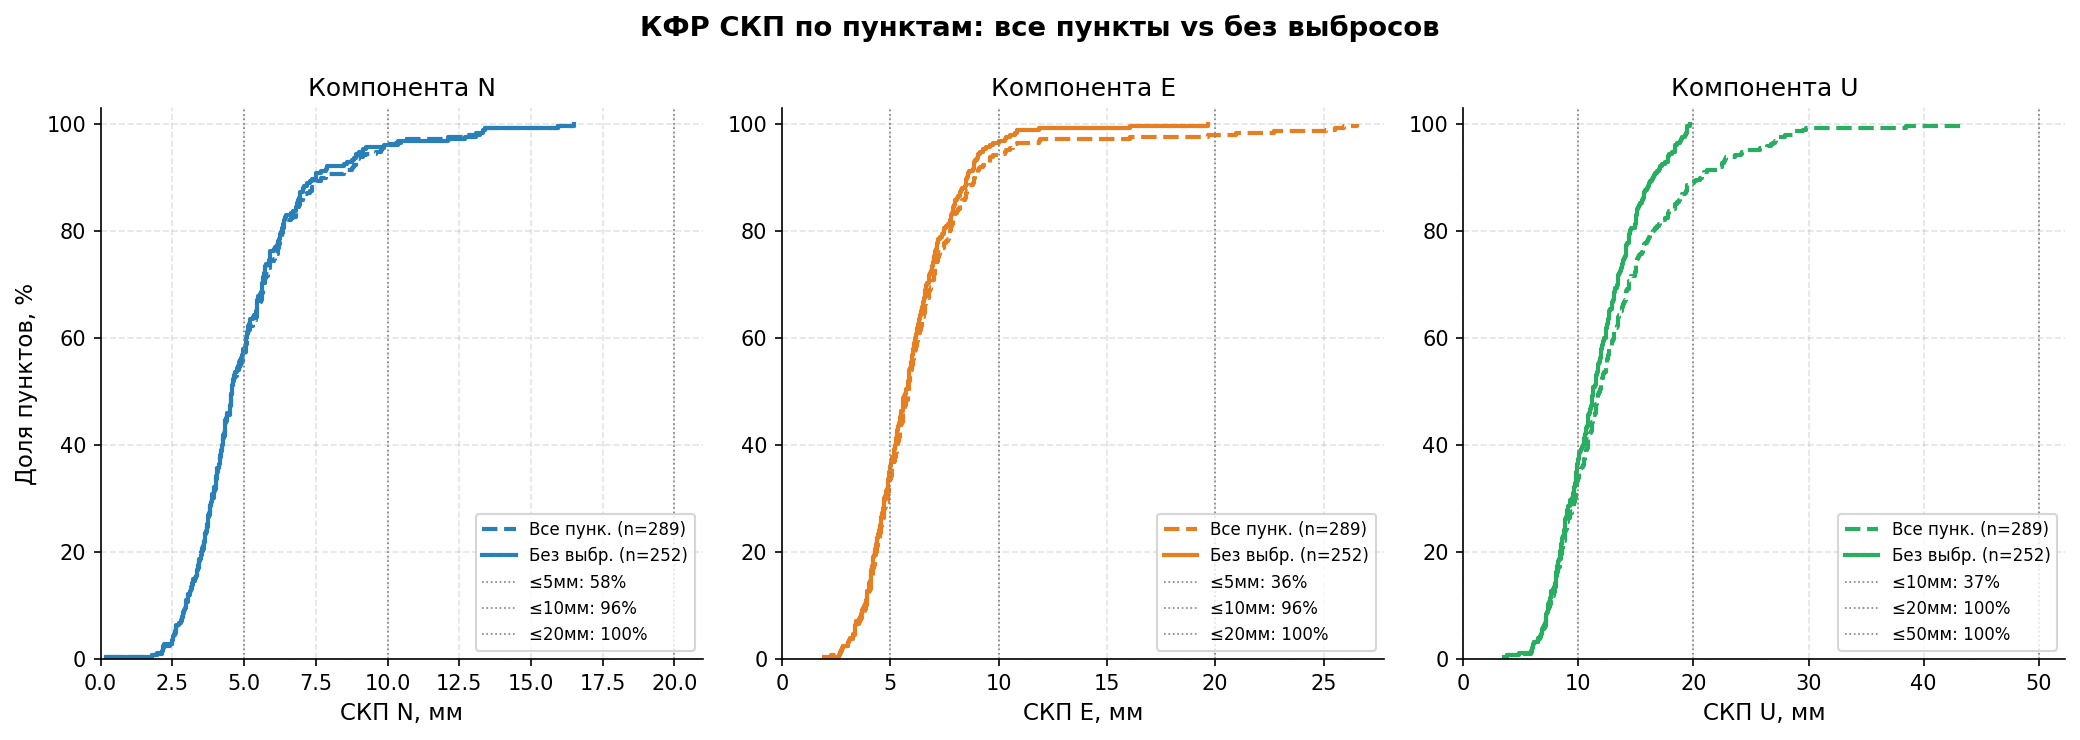


=== Итог для «чистой» выборки (252 пунктов) ===
  N: СКП=5.51мм  ДИ95=[5.43;5.59]  ≤5мм:58%  ≤10мм:96%  ≤20мм:100%
  E: СКП=6.34мм  ДИ95=[6.24;6.43]  ≤5мм:36%  ≤10мм:96%  ≤20мм:100%
  U: СКП=12.08мм  ДИ95=[11.91;12.27]  ≤10мм:37%  ≤20мм:100%  ≤50мм:100%
  Fix%=98.3%


In [18]:
# Данные только по «хорошим» пунктам
good_stations = set(st_good['station'])
df_good = df[df['station'].isin(good_stations)].copy()
df_good_fix = df_good[df_good['q'].isin(FIX_Q_VALUES)]

# ── Сравнение СКП до и после исключения ──────────────────────────────────────
comp_rows = []
for lbl, ds, ds_st in [('Все пункты (n={})'.format(len(st)), df, st),
                         ('Без выбросов (n={})'.format(len(st_good)), df_good, st_good)]:
    row = {'Выборка': lbl}
    for comp, key in [('dN_m','N'),('dE_m','E'),('dU_m','U')]:
        vals = ds[comp].values
        lo, hi = ci_rms(vals)
        row[f'μ {key}'] = f'{np.mean(vals)*1000:.2f}'
        row[f'σ {key}'] = f'{np.std(vals,ddof=1)*1000:.2f}'
        row[f'СКП {key}'] = f'{rms(vals)*1000:.2f}'
        row[f'ДИ95 {key}'] = f'[{lo*1000:.2f};{hi*1000:.2f}]'
    row['Fix%'] = f'{100*ds["q"].isin(FIX_Q_VALUES).sum()/len(ds):.1f}%'
    comp_rows.append(row)

df_comp = pd.DataFrame(comp_rows).set_index('Выборка')
print('=== Сравнение СКП до и после исключения пунктов с СКП > 20 мм (мм) ===')
display(df_comp)

# ── Гистограммы до/после ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f'Остатки PPP-AR: все пункты vs без выбросов (СКП > {OUTLIER_THR_MM:.0f} мм)',
             fontweight='bold')

for ax, col, lbl, clr in zip(axes,
        ['dN_m','dE_m','dU_m'], ['dN, мм','dE, мм','dU, мм'],
        [CLR['N'], CLR['E'], CLR['U']]):
    v_all  = df[col].values * 1000
    v_good = df_good[col].values * 1000
    lim = np.percentile(np.abs(v_all), 99.5) * 1.1
    bins = np.linspace(-lim, lim, 80)
    ax.hist(v_all,  bins=bins, density=True, color='#bdc3c7', alpha=0.7,
            label=f'Все ({rms(df[col].values)*1000:.1f}мм)')
    ax.hist(v_good, bins=bins, density=True, color=clr,       alpha=0.8,
            label=f'Без выбр. ({rms(df_good[col].values)*1000:.1f}мм)')
    # Нормальное распределение для «хороших»
    mu, sig = np.mean(v_good), np.std(v_good, ddof=1)
    x = np.linspace(-lim, lim, 300)
    ax.plot(x, sp_stats.norm.pdf(x, mu, sig), 'k-', lw=1.4)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel(lbl)
    ax.set_ylabel('Плотность' if ax is axes[0] else '')
    ax.set_title(f'СКП (без выбр.) = {rms(df_good[col].values)*1000:.2f} мм')
    ax.legend(fontsize=8)

plt.tight_layout()
savefig('10_hist_clean')
plt.show()

# ── КФР до/после ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('КФР СКП по пунктам: все пункты vs без выбросов', fontweight='bold')

for ax, col, comp, clr, thrs in zip(axes,
        ['rms_N','rms_E','rms_U'], ['N','E','U'],
        [CLR['N'],CLR['E'],CLR['U']],
        [GRADE_THR_H, GRADE_THR_H, GRADE_THR_V]):
    for ds_st, ls, lbl_line in [(st,'--','Все пунк.'), (st_good,'-','Без выбр.')]:
        sv = np.sort(ds_st[col].values)
        cdf = np.arange(1, len(sv)+1) / len(sv) * 100
        ax.step(sv, cdf, where='post', lw=2, color=clr, ls=ls,
                label=f'{lbl_line} (n={len(ds_st)})')
    for thr in thrs:
        pct_g = 100*(st_good[col].values <= thr).sum() / len(st_good)
        ax.axvline(thr, color='gray', lw=0.8, ls=':', label=f'≤{thr}мм: {pct_g:.0f}%')
    ax.set_xlabel(f'СКП {comp}, мм')
    ax.set_ylabel('Доля пунктов, %' if ax is axes[0] else '')
    ax.set_title(f'Компонента {comp}')
    ax.set_xlim(left=0)
    ax.set_ylim(0, 103)
    ax.legend(fontsize=8)

plt.tight_layout()
savefig('11_cdf_clean')
plt.show()

# ── Итоговая сводка «чистой» выборки ──────────────────────────────────────────
print(f'\n=== Итог для «чистой» выборки ({len(st_good)} пунктов) ===')
for col, lbl, thrs in [('rms_N','N',GRADE_THR_H),('rms_E','E',GRADE_THR_H),('rms_U','U',GRADE_THR_V)]:
    src = {'rms_N':'dN_m','rms_E':'dE_m','rms_U':'dU_m'}[col]
    r_g = rms(df_good[src].values)*1000
    lo, hi = ci_rms(df_good[src].values)
    pct_t = [100*(st_good[col]<=t).mean() for t in thrs]
    thr_str = '  '.join(f'≤{t}мм:{p:.0f}%' for t,p in zip(thrs,pct_t))
    print(f'  {lbl}: СКП={r_g:.2f}мм  ДИ95=[{lo*1000:.2f};{hi*1000:.2f}]  {thr_str}')
print(f'  Fix%={100*len(df_good_fix)/len(df_good):.1f}%')